In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras import layers, models
import numpy as np
import tensorflow as tf

In [2]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
import tensorflow as tf
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [6]:
from tensorflow.keras import layers, models

model = models.Sequential()

model.add(layers.Conv2D(150, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.AvgPool2D((2, 2)))

model.add(layers.Conv2D(200, (3, 3), activation='relu'))
model.add(layers.AvgPool2D((2, 2)))

model.add(layers.Conv2D(120, (3, 3), activation='relu'))
model.add(layers.AvgPool2D((2, 2)))

model.add(layers.Flatten())

model.add(layers.Dense(100, activation='relu'))
model.add(layers.Dense(200, activation='relu'))
model.add(layers.Dense(150, activation='relu'))

model.add(layers.Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 150)    │         1,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 13, 13, 150)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 200)    │       270,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 200)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 120)      │       216,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 1, 1, 120)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        12,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 150)            │        30,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,780 (2.10 MB)

 Trainable params: 551,780 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
epochs = 5

x_train_processed = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test_processed = x_test.reshape(x_test.shape[0], 28, 28, 1)

x_train_processed = x_train_processed.astype('float32') / 255.0
x_test_processed = x_test_processed.astype('float32') / 255.0

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train_processed, y_train,
                    epochs=epochs,
                    batch_size=120,
                    validation_data=(x_test_processed, y_tes
                    verbose=1)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 364s 725ms/step - accuracy: 0.8764 - loss: 0.3805 - val_accuracy: 0.9624 - val_loss: 0.1188
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 359s 719ms/step - accuracy: 0.9639 - loss: 0.1152 - val_accuracy: 0.9781 - val_loss: 0.0717
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 360s 721ms/step - accuracy: 0.9758 - loss: 0.0795 - val_accuracy: 0.9778 - val_loss: 0.0691
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 383s 724ms/step - accuracy: 0.9793 - loss: 0.0654 - val_accuracy: 0.9841 - val_loss: 0.0510
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 355s 711ms/step - accuracy: 0.9834 - loss: 0.0532 - val_accuracy: 0.9838 - val_loss: 0.0537


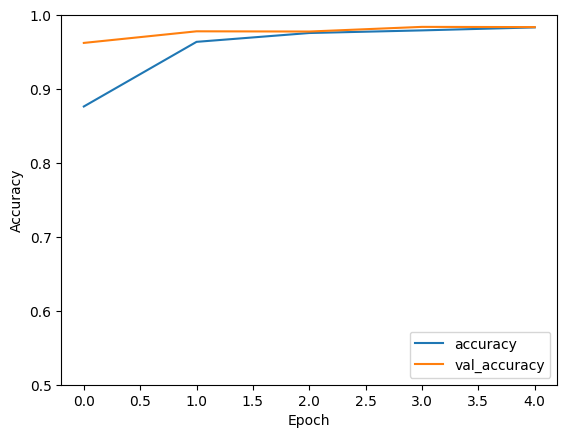

313/313 - 16s - 50ms/step - accuracy: 0.9838 - loss: 0.0537


In [8]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy') # Validation data was provided during training, so val_accuracy is available.
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show() # Added to display the plot

test_loss, test_acc = model.evaluate(x_test_processed,  y_test, verbose=2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


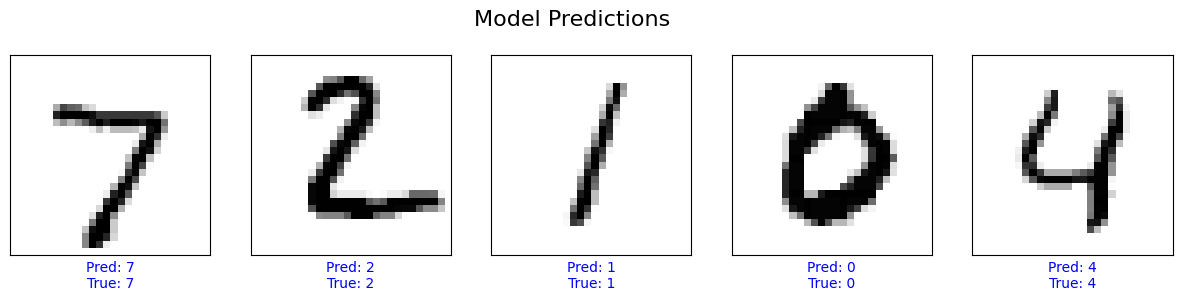

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Define class names for MNIST (digits 0-9)
class_names = [str(i) for i in range(10)]

def plot_predictions(model_obj, title, num_images=5):
    # Reshape x_test if necessary, assuming it's already processed to (10000, 28, 28, 1)
    # If not, use x_test_processed from earlier
    # For plotting, we might need the original 2D shape for imshow
    predictions = model_obj.predict(x_test_processed[:num_images]) # Use x_test_processed for prediction

    plt.figure(figsize=(15, 3))
    plt.suptitle(title, fontsize=16)
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(x_test[i], cmap=plt.cm.binary) # Use original x_test for displaying image

        predicted_label = np.argmax(predictions[i])
        true_label = y_test[i]

        color = 'blue' if predicted_label == true_label else 'red'
        plt.xlabel(f"Pred: {class_names[predicted_label]}\nTrue: {class_names[true_label]}", color=color)
    plt.show()

plot_predictions(model, "Model Predictions")